In [5]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
import pandas as  pd
import numpy as np

from scipy.spatial.distance import cosine
from colour import xyY_to_XYZ
from colour.models import XYZ_to_CAM16LCD
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer

In [3]:
analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/combvd/human_like/leeds', 'data/colors/combvd/leeds/manifest.csv') 

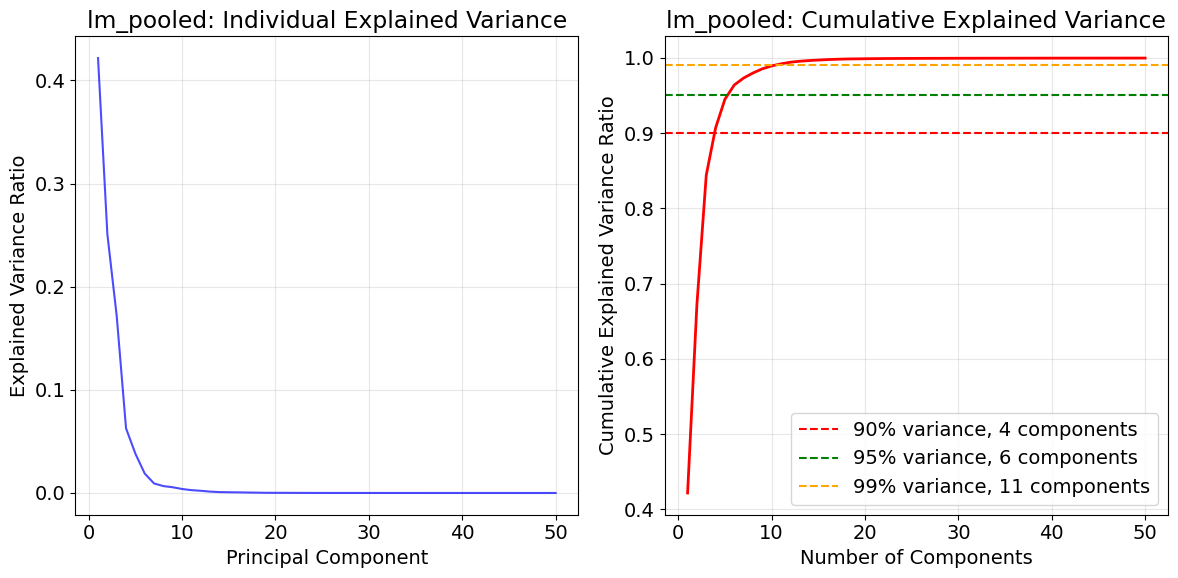

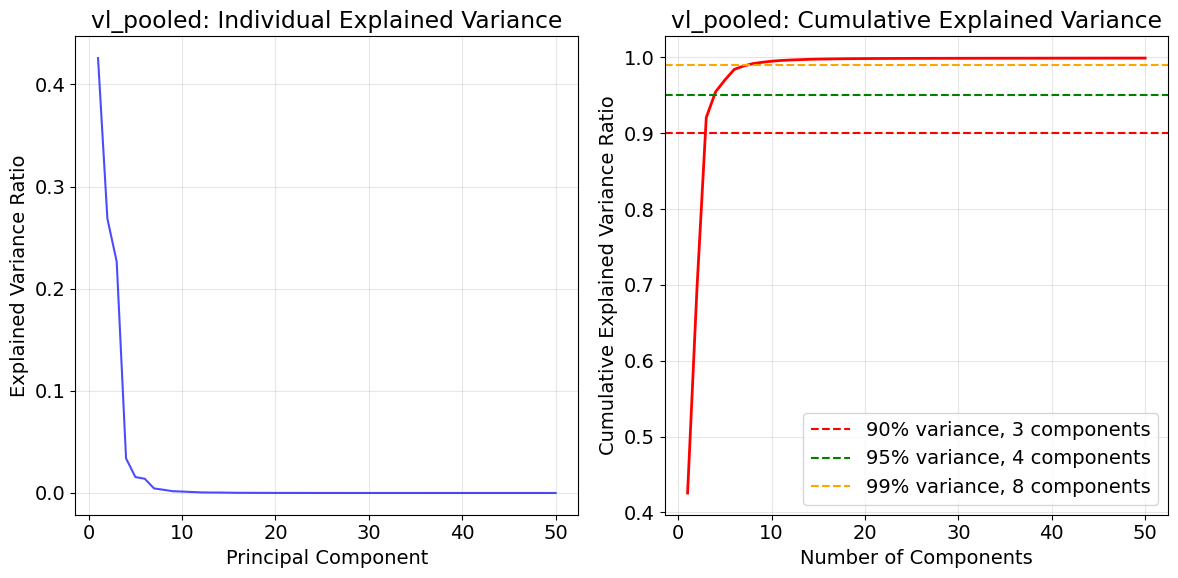

In [4]:
all_embeds = analyzer.chain_loader.get_all_available_embeddings()
pca_result = analyzer.pca_by_embeddings(all_embeds)

analyzer.plot_pca_variance(pca_result, embedding_name='lm_pooled')
analyzer.plot_pca_variance(pca_result, embedding_name='vl_pooled')

In [10]:
all_data = analyzer.chain_loader.get_all_available_embeddings()
lm = all_data["lm_pooled"]
vl = all_data["vl_pooled"]
meta = all_data["metadata"] 

colors_xyY = np.array([
    [item['xyY'][0], item['xyY'][1], item['xyY'][2]]
    for item in meta.values()
], dtype=float)
cam = [XYZ_to_CAM16LCD(xyY_to_XYZ(x)) for x in colors_xyY]


In [ ]:
import pandas as pd
from vsl_ial.datasets.distance import load_combvd

rows = []
for ds in load_combvd():  # witt, leeds, bfd_p-*, rit-dupont
    for (i, j), d in zip(ds.pairs, ds.dv):
        rows.append({
            "dataset": ds.name,
            "i": int(i),
            "j": int(j),
            "dv": float(d),
        })

pairs_df = pd.DataFrame(rows)
print(pairs_df[pairs_df['dataset' == ]].head())
pairs_df.to_csv("data/combvd_pairs.csv", index=False)

  dataset    i    j        dv
0    witt  482  477  0.573097
1    witt  482  487  0.866109
2    witt  482  475  1.133267
3    witt  482  473  1.503841
4    witt  482  471  1.745145


[LM] X=(482, 3584), pairs_train=192, pairs_val=49, dim=3584
Init A = alpha*I, alpha=0.154889, ||A||=9.2727
step=50/1500 train_loss(batch)=0.036117 ||grad||=0.859 ||A||=9.676
  [val objective] loss=0.464280
  [val dist] RMSE=0.261 MAE=0.213 MAPE=20.45% sMAPE=20.46% Pearson=0.7101 Spearman=0.6500
step=100/1500 train_loss(batch)=0.052148 ||grad||=1.374 ||A||=9.720
  [val objective] loss=0.361235
  [val dist] RMSE=0.239 MAE=0.196 MAPE=18.71% sMAPE=19.01% Pearson=0.7555 Spearman=0.7011
step=150/1500 train_loss(batch)=0.047801 ||grad||=1.237 ||A||=9.771
  [val objective] loss=0.612444
  [val dist] RMSE=0.284 MAE=0.225 MAPE=21.90% sMAPE=20.84% Pearson=0.7010 Spearman=0.6354
step=200/1500 train_loss(batch)=0.054472 ||grad||=1.425 ||A||=9.810
  [val objective] loss=0.491400
  [val dist] RMSE=0.267 MAE=0.223 MAPE=21.52% sMAPE=21.30% Pearson=0.6968 Spearman=0.6203
step=250/1500 train_loss(batch)=0.024638 ||grad||=0.611 ||A||=9.821
  [val objective] loss=0.384518
  [val dist] RMSE=0.256 MAE=0.212 

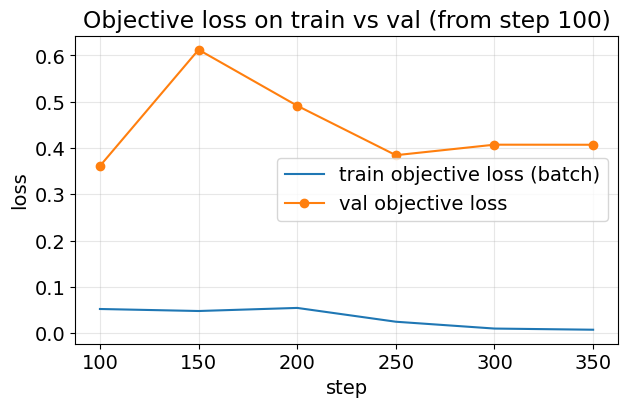

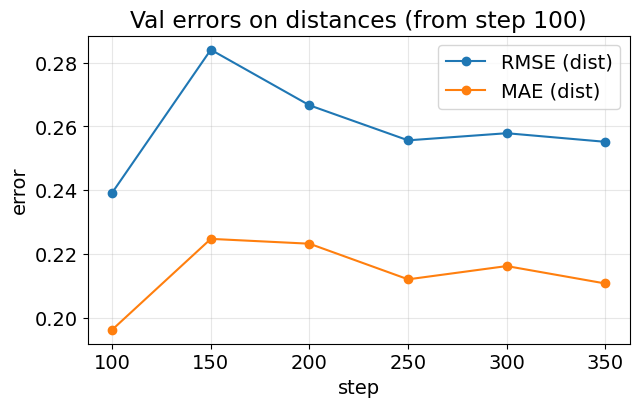

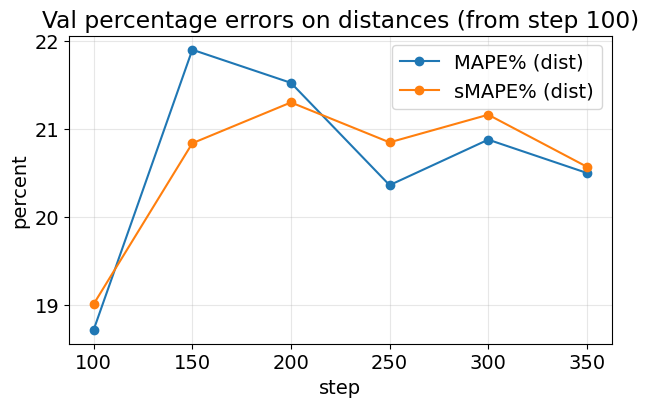

Best by VAL LOSS: step=100 val_loss=0.361235
  [best val dist] RMSE=0.239 MAE=0.196 MAPE=18.71% sMAPE=19.01% Pearson=0.7555 Spearman=0.7011
[LM] FINAL val objective loss=0.361235
[LM] FINAL val distances: RMSE=0.239 MAE=0.196 MAPE=18.71% sMAPE=19.01% Pearson=0.7555 Spearman=0.7011
------------------------------
[Vision] X=(482, 3584), pairs_train=192, pairs_val=49, dim=3584
Init A = alpha*I, alpha=0.821031, ||A||=49.1522
step=50/1500 train_loss(batch)=0.042640 ||grad||=0.072 ||A||=50.577
  [val objective] loss=0.366564
  [val dist] RMSE=0.225 MAE=0.180 MAPE=16.90% sMAPE=17.32% Pearson=0.7708 Spearman=0.7636
step=100/1500 train_loss(batch)=0.011810 ||grad||=0.057 ||A||=50.897
  [val objective] loss=0.353228
  [val dist] RMSE=0.218 MAE=0.166 MAPE=15.33% sMAPE=15.72% Pearson=0.7784 Spearman=0.7893
step=150/1500 train_loss(batch)=0.013928 ||grad||=0.079 ||A||=50.958
  [val objective] loss=0.391979
  [val dist] RMSE=0.225 MAE=0.171 MAPE=15.99% sMAPE=16.12% Pearson=0.7658 Spearman=0.7650
ste

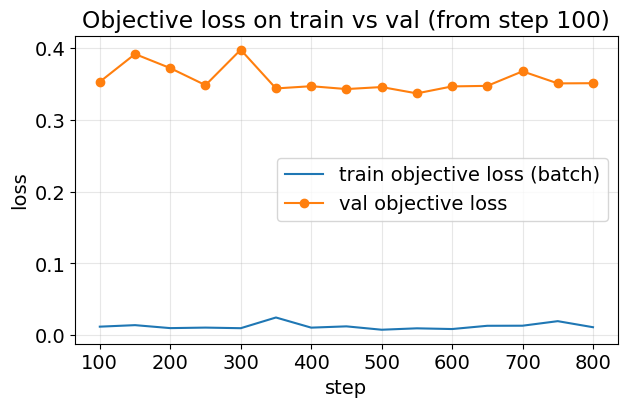

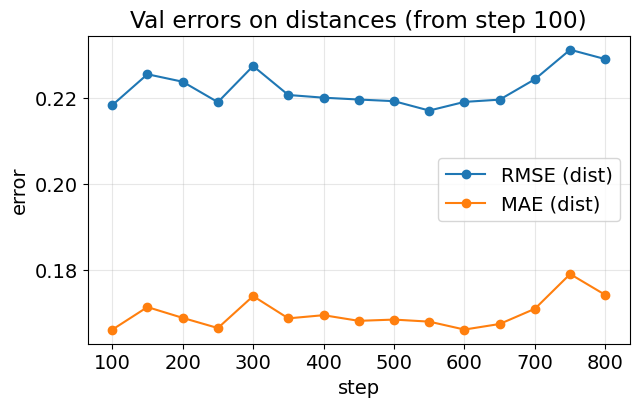

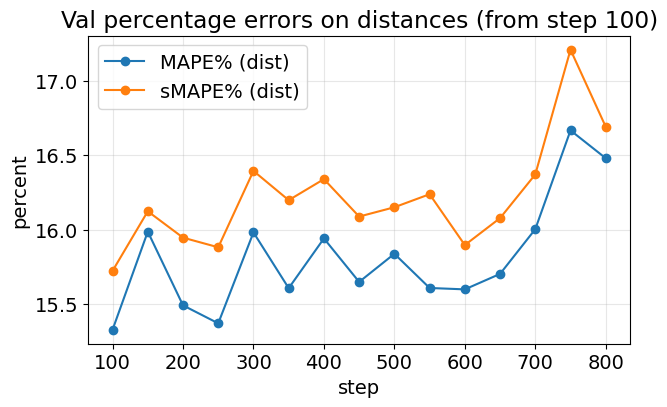

Best by VAL LOSS: step=550 val_loss=0.337113
  [best val dist] RMSE=0.217 MAE=0.168 MAPE=15.61% sMAPE=16.24% Pearson=0.7824 Spearman=0.7973
[Vision] FINAL val objective loss=0.337113
[Vision] FINAL val distances: RMSE=0.217 MAE=0.168 MAPE=15.61% sMAPE=16.24% Pearson=0.7824 Spearman=0.7973


In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


# ============================================================
# 0) Utils
# ============================================================

def sanitize_X(X):
    X = np.asarray(X, dtype=np.float32)
    m = np.isfinite(X).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize_X: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], m  # m нужен, если захотите ремапить индексы после фильтрации


def safe_corr(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if len(y_true) < 2:
        return np.nan, np.nan
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return np.nan, np.nan

    pr = float(pearsonr(y_true, y_pred)[0])
    sr = spearmanr(y_true, y_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))
    return pr, sr_r


def prepare_pairs_df(pairs_df, n_objects, dataset_name=None):
    """
    Ожидает колонки:
      - i, j: индексы объектов
      - dv: целевое расстояние (НЕ квадрат)
      - (опционально) dataset
    """
    p = pairs_df.copy()

    if dataset_name is not None:
        if "dataset" not in p.columns:
            raise ValueError("pairs_df has no 'dataset' column, but dataset_name was provided.")
        p = p[p["dataset"] == dataset_name].copy()

    required = {"i", "j", "dv"}
    missing = required - set(p.columns)
    if missing:
        raise ValueError(f"pairs_df missing required columns: {missing}")

    p = p[np.isfinite(p["i"]) & np.isfinite(p["j"]) & np.isfinite(p["dv"])].copy()
    p["i"] = p["i"].astype(np.int64)
    p["j"] = p["j"].astype(np.int64)
    p["dv"] = p["dv"].astype(np.float32)

    p = p[(p["i"] >= 0) & (p["j"] >= 0) & (p["i"] < n_objects) & (p["j"] < n_objects)]
    p = p[p["i"] != p["j"]]

    # canonical order i<j
    i = p["i"].to_numpy()
    j = p["j"].to_numpy()
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    p = p.copy()
    p["i"] = i2
    p["j"] = j2

    # убрать дубликаты пар (если есть), усреднить dv
    p = p.groupby(["i", "j"], as_index=False)["dv"].mean()

    if len(p) == 0:
        raise ValueError("No valid pairs left after filtering.")

    return p


def make_pair_batch_from_pairs(X, i, j, d_true):
    """
    returns:
      V:  (B,n) = X[i]-X[j]
      t2: (B,)  = d_true^2
    """
    V = X[i] - X[j]
    t2 = d_true * d_true
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2


def compute_pred_true_for_pairs(X, A, i, j, d_true):
    """
    returns arrays:
      t      = d_true
      pred   = AΔx
      t2     = d_true^2
      pred2  = ||AΔx||^2
    """
    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    t = np.asarray(d_true, dtype=np.float32)
    t2 = t * t

    m = np.isfinite(t) & np.isfinite(pred) & np.isfinite(t2) & np.isfinite(pred2)
    return t[m], pred[m], t2[m], pred2[m]


# ============================================================
# 1) Objective for FULL A (n x n): squared-distances objective
#    L = mean ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)                  # ||A v||^2
    e = (s - t2)                                 # (B,)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)             # (B,)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])  # (n,n)
    return loss, grad


# ============================================================
# 2) AdamW (float32) + grad clipping
# ============================================================
class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1.0 - self.b1) * grad
        self.v = self.b2 * self.v + (1.0 - self.b2) * (grad * grad)

        mhat = self.m / (1.0 - self.b1 ** self.t)
        vhat = self.v / (1.0 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Metrics on DISTANCES (not squared)
# ============================================================

def dist_errors(d_true, d_pred, eps=1e-6):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)

    err = d_pred - d_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(d_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / np.maximum(np.abs(d_true) + np.abs(d_pred), eps)) * 100.0)

    pr, sr = safe_corr(d_true, d_pred)
    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape, "pearson": pr, "spearman": sr}


def estimate_val_loss_sq_objective_pairs(X, A, i, j, d_true, max_eval_pairs=None, rng=None):
    if max_eval_pairs is not None and len(i) > max_eval_pairs:
        if rng is None:
            rng = np.random.default_rng(0)
        idx = rng.choice(len(i), size=max_eval_pairs, replace=False)
        i, j, d_true = i[idx], j[idx], d_true[idx]

    V, t2 = make_pair_batch_from_pairs(X, i, j, d_true)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))


def eval_dist_metrics_pairs(X, A, i, j, d_true, max_eval_pairs=None, rng=None):
    if max_eval_pairs is not None and len(i) > max_eval_pairs:
        if rng is None:
            rng = np.random.default_rng(0)
        idx = rng.choice(len(i), size=max_eval_pairs, replace=False)
        i, j, d_true = i[idx], j[idx], d_true[idx]

    d_true_arr, d_pred_arr, _, _ = compute_pred_true_for_pairs(X, A, i, j, d_true)
    return dist_errors(d_true_arr, d_pred_arr)


# ============================================================
# 4) Init: A = alpha * I
# ============================================================

def init_alphaI_from_pairs(X, i, j, d_true, eps=1e-12):
    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)         # ||Δx||^2
    dy2 = d_true * d_true                 # target^2

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop on explicit pairs_df
# ============================================================

def fit_fullA_distance_squares_pairs(
    X,
    i_train, j_train, d_train,
    i_val, j_val, d_val,
    n_steps=1200,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    log_every=50,
    val_every=200,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
    max_eval_pairs=80_000,
):
    rng = np.random.default_rng(seed)
    n_dim = X.shape[1]

    alpha = init_alphaI_from_pairs(X, i_train, j_train, d_train)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    # histories
    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []
    hist_val_rmse, hist_val_mae, hist_val_mape, hist_val_smape = [], [], [], []

    best = {"val_loss": np.inf, "A": A.copy(), "step": 0, "val_dist": None}
    bad_count = 0

    n_train_pairs = len(i_train)
    if n_train_pairs == 0:
        raise ValueError("No training pairs.")
    if len(i_val) == 0:
        raise ValueError("No validation pairs.")

    for step in range(1, n_steps + 1):
        bsz = min(batch_size, n_train_pairs)
        idx = rng.integers(0, n_train_pairs, size=bsz, endpoint=False)

        i_b = i_train[idx]
        j_b = j_train[idx]
        d_b = d_train[idx]

        V, t2 = make_pair_batch_from_pairs(X, i_b, j_b, d_b)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            val_loss = estimate_val_loss_sq_objective_pairs(
                X, A, i_val, j_val, d_val, max_eval_pairs=max_eval_pairs, rng=rng
            )
            val_dist = eval_dist_metrics_pairs(
                X, A, i_val, j_val, d_val, max_eval_pairs=max_eval_pairs, rng=rng
            )

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)
            hist_val_rmse.append(val_dist["rmse"])
            hist_val_mae.append(val_dist["mae"])
            hist_val_mape.append(val_dist["mape"])
            hist_val_smape.append(val_dist["smape"])

            print(f"step={step}/{n_steps} train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")
            print(f"  [val dist] RMSE={val_dist['rmse']:.3f} MAE={val_dist['mae']:.3f} "
                  f"MAPE={val_dist['mape']:.2f}% sMAPE={val_dist['smape']:.2f}% "
                  f"Pearson={val_dist['pearson']:.4f} Spearman={val_dist['spearman']:.4f}")

            if val_loss < best["val_loss"] - min_delta:
                best = {"val_loss": val_loss, "A": A.copy(), "step": step, "val_dist": val_dist}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(
                        f"Early stopping at step={step}: no improvement in VAL LOSS for {patience} validations. "
                        f"Best step={best['step']} val_loss={best['val_loss']:.6f}"
                    )
                    break

    # ---------- plots ----------
    tr_s = np.array(hist_train_steps, dtype=int)
    tr_l = np.array(hist_train_loss, dtype=float)
    va_s = np.array(hist_val_steps, dtype=int)
    va_l = np.array(hist_val_loss, dtype=float)

    m_tr = tr_s >= plot_from_step
    m_va = va_s >= plot_from_step

    plt.figure(figsize=(7, 4))
    if m_tr.any():
        plt.plot(tr_s[m_tr], tr_l[m_tr], label="train objective loss (batch)")
    if m_va.any():
        plt.plot(va_s[m_va], va_l[m_va], marker="o", label="val objective loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(f"Objective loss on train vs val (from step {plot_from_step})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if len(hist_val_steps) > 0 and m_va.any():
        plt.figure(figsize=(7, 4))
        plt.plot(va_s[m_va], np.array(hist_val_rmse)[m_va], marker="o", label="RMSE (dist)")
        plt.plot(va_s[m_va], np.array(hist_val_mae)[m_va], marker="o", label="MAE (dist)")
        plt.xlabel("step")
        plt.ylabel("error")
        plt.title(f"Val errors on distances (from step {plot_from_step})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


    plt.figure(figsize=(7, 4))
    plt.plot(va_s[m_va], np.array(hist_val_mape)[m_va], marker="o", label="MAPE% (dist)")
    plt.plot(va_s[m_va], np.array(hist_val_smape)[m_va], marker="o", label="sMAPE% (dist)")
    plt.xlabel("step")
    plt.ylabel("percent")
    plt.title(f"Val percentage errors on distances (from step {plot_from_step})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_dist"] is not None:
        d = best["val_dist"]
        print(f"  [best val dist] RMSE={d['rmse']:.3f} MAE={d['mae']:.3f} "
              f"MAPE={d['mape']:.2f}% sMAPE={d['smape']:.2f}% "
              f"Pearson={d['pearson']:.4f} Spearman={d['spearman']:.4f}")

    history = {
        "train_steps": tr_s,
        "train_loss": tr_l,
        "val_steps": va_s,
        "val_loss": va_l,
        "val_dist_rmse": np.array(hist_val_rmse, dtype=float),
        "val_dist_mae": np.array(hist_val_mae, dtype=float),
        "val_dist_mape": np.array(hist_val_mape, dtype=float),
        "val_dist_smape": np.array(hist_val_smape, dtype=float),
    }
    return best, history


# ============================================================
# 6) End-to-end runner for pairs_df
# ============================================================

def run_fullA_experiment_pairs(
    embeddings,
    pairs_df,
    dataset_name='leeds',          # например "witt" / "leeds" / ...
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1500,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
    max_eval_pairs=80_000,
):
    X, mask_valid = sanitize_X(embeddings)

    # ВАЖНО:
    # если sanitize_X выкинул строки, индексы пар уже не совпадут.
    # Для простоты требуем, чтобы ничего не выкинулось.
    if not np.all(mask_valid):
        raise ValueError(
            "embeddings contain NaN/Inf. Fix embeddings first, "
            "otherwise pair indices no longer match object rows."
        )

    p = prepare_pairs_df(pairs_df, n_objects=X.shape[0], dataset_name=dataset_name)

    i_all = p["i"].to_numpy(dtype=np.int64)
    j_all = p["j"].to_numpy(dtype=np.int64)
    d_all = p["dv"].to_numpy(dtype=np.float32)

    idx = np.arange(len(p))
    idx_tr, idx_te = train_test_split(idx, test_size=test_size, random_state=random_state, shuffle=True)

    i_tr, j_tr, d_tr = i_all[idx_tr], j_all[idx_tr], d_all[idx_tr]
    i_te, j_te, d_te = i_all[idx_te], j_all[idx_te], d_all[idx_te]

    print(f"[{layer_name}] X={X.shape}, pairs_train={len(i_tr)}, pairs_val={len(i_te)}, dim={X.shape[1]}")

    best, history = fit_fullA_distance_squares_pairs(
        X,
        i_tr, j_tr, d_tr,
        i_te, j_te, d_te,
        n_steps=n_steps,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        patience=patience,
        min_delta=min_delta,
        plot_from_step=plot_from_step,
        max_eval_pairs=max_eval_pairs,
    )

    A_best = best["A"]

    final_loss = estimate_val_loss_sq_objective_pairs(
        X, A_best, i_te, j_te, d_te, max_eval_pairs=200_000, rng=np.random.default_rng(999)
    )
    final_dist = eval_dist_metrics_pairs(
        X, A_best, i_te, j_te, d_te, max_eval_pairs=200_000, rng=np.random.default_rng(1002)
    )

    print(f"[{layer_name}] FINAL val objective loss={final_loss:.6f}")
    print(f"[{layer_name}] FINAL val distances: "
          f"RMSE={final_dist['rmse']:.3f} MAE={final_dist['mae']:.3f} "
          f"MAPE={final_dist['mape']:.2f}% sMAPE={final_dist['smape']:.2f}% "
          f"Pearson={final_dist['pearson']:.4f} Spearman={final_dist['spearman']:.4f}")

    return {
        "A": A_best,
        "best": best,
        "history": history,
        "final": {"loss": final_loss, "dist": final_dist},
        "pairs_used": p,
    }

# ============================================================
# Usage:
# pairs_df columns: dataset, i, j, dv
out_lm = run_fullA_experiment_pairs(lm, pairs_df, dataset_name="leeds", layer_name="LM")
print("-" * 30)
out_vl = run_fullA_experiment_pairs(vl, pairs_df, dataset_name="leeds", layer_name="Vision")
# ============================================================

In [22]:
import numpy as np
import pandas as pd
from vsl_ial.stress import stress


def prepare_pairs_df(pairs_df, n_objects, dataset_name=None):
    p = pairs_df.copy()

    if dataset_name is not None:
        if "dataset" not in p.columns:
            raise ValueError("dataset_name задан, но в pairs_df нет колонки 'dataset'")
        p = p[p["dataset"] == dataset_name].copy()

    for c in ("i", "j", "dv"):
        if c not in p.columns:
            raise ValueError(f"В pairs_df нет колонки '{c}'")

    p["i"] = pd.to_numeric(p["i"], errors="coerce")
    p["j"] = pd.to_numeric(p["j"], errors="coerce")
    p["dv"] = pd.to_numeric(p["dv"], errors="coerce")
    p = p[np.isfinite(p["i"]) & np.isfinite(p["j"]) & np.isfinite(p["dv"])].copy()

    p["i"] = p["i"].astype(np.int64)
    p["j"] = p["j"].astype(np.int64)
    p["dv"] = p["dv"].astype(np.float64)

    p = p[(p["i"] >= 0) & (p["j"] >= 0) & (p["i"] < n_objects) & (p["j"] < n_objects)]
    p = p[p["i"] != p["j"]]
    p = p[p["dv"] >= 0.0]

    # canonical i<j + dedup
    i = p["i"].to_numpy()
    j = p["j"].to_numpy()
    p["i"] = np.minimum(i, j)
    p["j"] = np.maximum(i, j)
    p = p.groupby(["i", "j"], as_index=False)["dv"].mean()

    if len(p) == 0:
        raise ValueError("После фильтрации не осталось валидных пар")
    return p


def pairwise_pred_from_pairs(X, A, i, j, chunk_size=20_000):
    X = np.asarray(X, dtype=np.float64)
    A = np.asarray(A, dtype=np.float64)

    d_pred = np.empty(i.shape[0], dtype=np.float64)
    for s in range(0, i.shape[0], chunk_size):
        e = min(s + chunk_size, i.shape[0])
        ii, jj = i[s:e], j[s:e]
        dX = X[ii] - X[jj]
        AdX = dX @ A.T
        d_pred[s:e] = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))
    return d_pred


def compare_stress_only(lm, vl, out_lm, out_vl, pairs_df, dataset_name=None):
    X_lm = np.asarray(lm, dtype=np.float64)
    X_vl = np.asarray(vl, dtype=np.float64)

    if X_lm.shape[0] != X_vl.shape[0]:
        raise ValueError(f"lm/vl mismatch: {X_lm.shape[0]} vs {X_vl.shape[0]}")

    n = X_lm.shape[0]
    p = prepare_pairs_df(pairs_df, n_objects=n, dataset_name=dataset_name)

    i = p["i"].to_numpy(dtype=np.int64)
    j = p["j"].to_numpy(dtype=np.int64)
    d_target = p["dv"].to_numpy(dtype=np.float64)

    d_emb_A_lm = pairwise_pred_from_pairs(X_lm, out_lm["A"], i, j)
    d_emb_A_vl = pairwise_pred_from_pairs(X_vl, out_vl["A"], i, j)

    m_lm = np.isfinite(d_emb_A_lm) & np.isfinite(d_target)
    m_vl = np.isfinite(d_emb_A_vl) & np.isfinite(d_target)

    print(f"Pairs used (LM): {m_lm.sum()} / {len(d_target)}")
    print(f"Pairs used (Vision): {m_vl.sum()} / {len(d_target)}")
    if dataset_name is not None:
        print(f"Dataset: {dataset_name}")

    print(f"Stress LM (ord=2):     {stress(d_emb_A_lm[m_lm], d_target[m_lm], ord=2):.6f}")
    print(f"Stress Vision (ord=2): {stress(d_emb_A_vl[m_vl], d_target[m_vl], ord=2):.6f}")


# Usage:
compare_stress_only(lm, vl, out_lm, out_vl, pairs_df, dataset_name="leeds")

Pairs used (LM): 241 / 241
Pairs used (Vision): 241 / 241
Dataset: leeds
Stress LM (ord=2):     0.127500
Stress Vision (ord=2): 0.095980
